# ML - SUPERVISED LEARNING
## Naive Bayes
**News Category Prediction**

In [1]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# 1. Dataset
# ---------------------------------------------------------------
data = {
    "Article": [
        "cricket team won match",
        "football player scored goal",
        "cricket player hit century",

        "new smartphone launched",
        "artificial intelligence improves software",
        "new laptop has powerful processor",

        "government announced new policy",
        "election campaign started",
        "minister announced new scheme"
    ],
    "Category": [
        "Sports", "Sports", "Sports",
        "Technology", "Technology", "Technology",
        "Politics", "Politics", "Politics"
    ]
}
df = pd.DataFrame(data)
print(df, "\n")

                                     Article    Category
0                     cricket team won match      Sports
1                football player scored goal      Sports
2                 cricket player hit century      Sports
3                    new smartphone launched  Technology
4  artificial intelligence improves software  Technology
5          new laptop has powerful processor  Technology
6            government announced new policy    Politics
7                  election campaign started    Politics
8              minister announced new scheme    Politics 



In [2]:
# ---------------------------------------------------------------
# 2. Preprocess: split into tokens, build vocabulary
# ---------------------------------------------------------------
df["Tokens"] = df["Article"].str.lower().str.split()

vocabulary = sorted({word for tokens in df["Tokens"] for word in tokens})
V = len(vocabulary)                      # vocabulary size (for smoothing)

classes = sorted(df["Category"].unique())
N = len(df)                              # total documents

print("Vocabulary:", vocabulary)
print("Vocabulary size V =", V)
print("Classes:", classes, "\n")

Vocabulary: ['announced', 'artificial', 'campaign', 'century', 'cricket', 'election', 'football', 'goal', 'government', 'has', 'hit', 'improves', 'intelligence', 'laptop', 'launched', 'match', 'minister', 'new', 'player', 'policy', 'powerful', 'processor', 'scheme', 'scored', 'smartphone', 'software', 'started', 'team', 'won']
Vocabulary size V = 29
Classes: ['Politics', 'Sports', 'Technology'] 



In [3]:
# ---------------------------------------------------------------
# 3. Prior probabilities  P(Category)
# ---------------------------------------------------------------
sports_count      = np.sum(df["Category"] == "Sports")
technology_count  = np.sum(df["Category"] == "Technology")
politics_count    = np.sum(df["Category"] == "Politics")
total_count       = len(df)

p_sports      = sports_count / total_count
p_technology  = technology_count / total_count
p_politics    = politics_count / total_count

print("p_sports     =", p_sports)
print("p_technology =", p_technology)
print("p_politics   =", p_politics)
print()

p_sports     = 0.3333333333333333
p_technology = 0.3333333333333333
p_politics   = 0.3333333333333333



In [4]:
# ---------------------------------------------------------------
# 4. Word counts per category (for likelihood + Laplace smoothing)
# ---------------------------------------------------------------
def word_probablity(word, class_name):
    articles = df[df["Category"] == class_name]["Article"]
    count = 0
    for article in articles:
        words = article.lower().split()
        if word in words:
            count += 1
        class_count = len(articles)
        probablity = (count + 1) / (class_count + V)   # V = vocabulary size
    return probablity


In [5]:
# ---------- classify an article word by word ----------
def classify(article):
    words = article.lower().split()

    # start each score at the prior probability
    scores = {
        "Sports":     p_sports,
        "Technology": p_technology,
        "Politics":   p_politics,
    }

    # multiply in P(word | category) for every word
    for word in words:
        for category in scores:
            scores[category] *= word_probablity(word, category)

    # pick the category with the highest score
    prediction = max(scores, key=scores.get)

    # print results
    print(f'Article: "{article}"')
    for category, score in scores.items():
        print(f"  {category:<11} score = {score}")
    print("  prediction =", prediction)
    print()

    return prediction, scores


In [11]:
# Run the required test
new_article = "cricket player won match"
prediction, scores = classify(new_article)

Article: "cricket player won match"
  Sports      score = 1.1444091796875e-05
  Technology  score = 3.178914388020833e-07
  Politics    score = 3.178914388020833e-07
  prediction = Sports



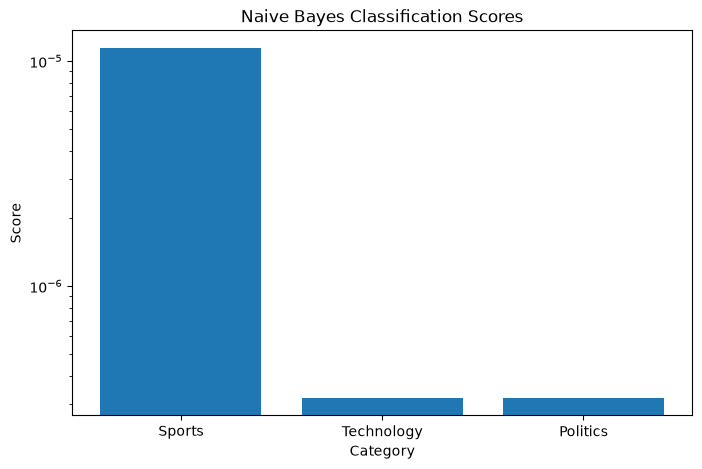

In [12]:
import matplotlib.pyplot as plt

categories = list(scores.keys())
values = list(scores.values())

plt.figure(figsize=(8, 5))

plt.bar(categories, values)

plt.title("Naive Bayes Classification Scores")
plt.xlabel("Category")
plt.ylabel("Score")

plt.yscale("log")

plt.show()

In [13]:
new_article = "new smartphone software"
prediction, scores = classify(new_article)

Article: "new smartphone software"
  Sports      score = 1.0172526041666666e-05
  Technology  score = 0.0001220703125
  Politics    score = 3.0517578125e-05
  prediction = Technology



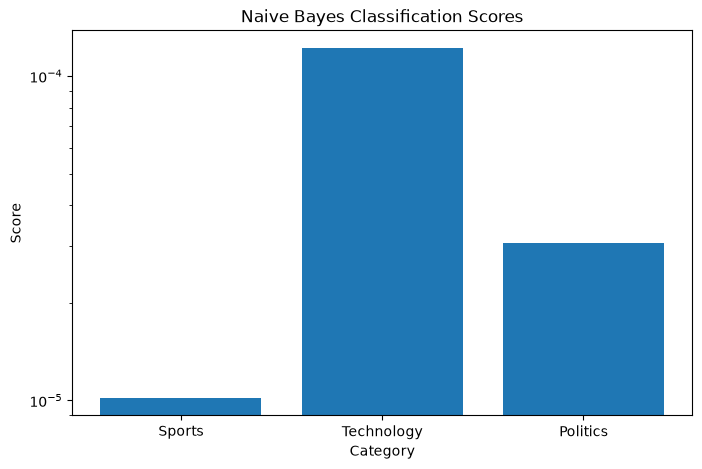

In [14]:
categories = list(scores.keys())
values = list(scores.values())

plt.figure(figsize=(8, 5))

plt.bar(categories, values)

plt.title("Naive Bayes Classification Scores")
plt.xlabel("Category")
plt.ylabel("Score")

plt.yscale("log")

plt.show()

In [15]:
new_article = "government election policy"
prediction, scores = classify(new_article)

Article: "government election policy"
  Sports      score = 1.0172526041666666e-05
  Technology  score = 1.0172526041666666e-05
  Politics    score = 8.138020833333333e-05
  prediction = Politics

